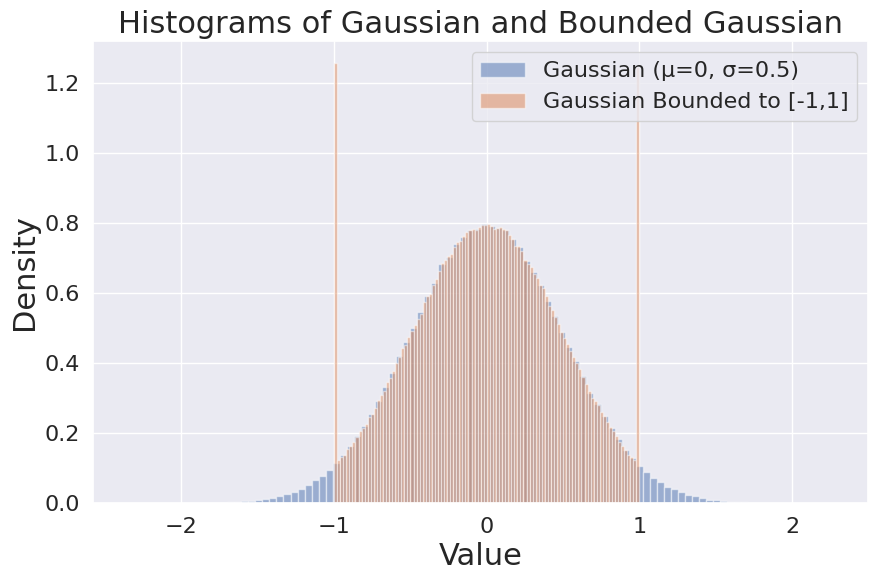

In [20]:
import numpy as np
import matplotlib.pyplot as plt

# Number of samples
n = 1000000

# Generate Gaussian random samples with std=1 and mean=0.
data = np.random.normal(loc=0., scale=0.5, size=n)

# Generate second Gaussian distribution with mean sqrt(0.2) and std 1
data2 = np.random.normal(loc=0.+np.sqrt(0.2), scale=0.5, size=n)


# Clip the data: limit values to be within [-1, 1]
data_bounded = np.clip(data, -1, 1)
data_bounded2 = np.clip(data2, -1, 1)

# Clip the data using tanh
data_tanh = np.tanh(data)
data_tanh2 = np.tanh(data2)

# Create new figure for the superposed histograms
plt.figure(figsize=(10, 6))

# Plot histogram of the full Gaussian data (mean 0, std 1)
plt.hist(data, bins=100, density=True, alpha=0.5, label='Gaussian (μ=0, σ=0.5)')

# Plot histogram of the bounded Gaussian data (only values in [-1,1])
plt.hist(data_bounded, bins=100, density=True, alpha=0.5, label='Gaussian Bounded to [-1,1]')
#plt.hist(data_bounded2, bins=100, density=True, alpha=0.5, label='Gaussian Bounded to [-1,1]')

plt.xlabel('Value', fontsize=22)
plt.ylabel('Density', fontsize=22)
plt.title('Histograms of Gaussian and Bounded Gaussian', fontsize=22)
plt.legend(fontsize=16)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.savefig("./plots/bound/clipped_gaussian.pdf", format="pdf", bbox_inches="tight")
plt.show()

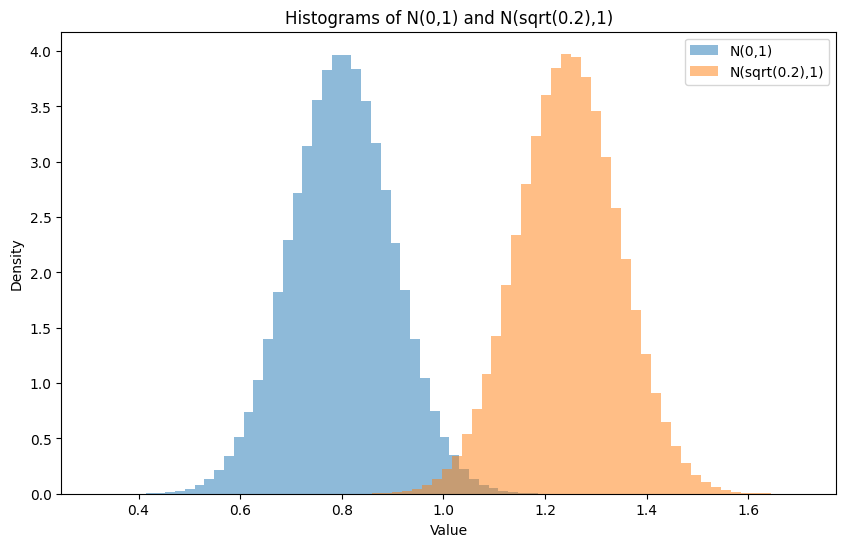

In [3]:

# Create a new figure for the new histograms
plt.figure(figsize=(10, 6))

# Plot the histogram for the standard Gaussian N(0,1)
plt.hist(data, bins=50, density=True, alpha=0.5, label='N(0,1)')

# Plot the histogram for the Gaussian N(sqrt(0.2),1)
plt.hist(data2, bins=50, density=True, alpha=0.5, label='N(sqrt(0.2),1)')

plt.xlabel('Value')
plt.ylabel('Density')
plt.title('Histograms of N(0,1) and N(sqrt(0.2),1)')
plt.legend()
plt.show()

In [4]:
def compute_clipping_ratios(data,data2):

    # Use common bins for both histograms
    bins = np.linspace(min(np.min(data), np.min(data2)),
                    max(np.max(data), np.max(data2)),
                    51)

    # Calculate density histograms
    h1, _ = np.histogram(data, bins=bins, density=True)
    h2, _ = np.histogram(data2, bins=bins, density=True)
    bin_centers = (bins[:-1] + bins[1:]) / 2

    # Compute the ratio (handle division by zero)
    ratio = np.divide(h1, h2, out=np.full_like(h1, np.nan), where=h2>1e-10)

    # Identify the maximum ratio
    max_ratio = np.nanmax(ratio)
    max_index = np.nanargmax(ratio)
    median_ratio = np.nanmedian(ratio)

    # # Plot the ratio vs bin centers and mark the maximum ratio
    # plt.figure(figsize=(10, 6))
    # plt.bar(bin_centers, ratio, width=bins[1]-bins[0], alpha=0.5, label='Probability Ratio (data/data2)')
    # plt.axhline(max_ratio, color='red', linestyle='--', 
    #             label=f'Max Ratio = {max_ratio:.2f} at {bin_centers[max_index]:.2f}')
    # plt.axhline(median_ratio, color='green', linestyle='--',
    #             label=f'Median Ratio = {median_ratio:.2f}')
    # plt.xlabel('Value')
    # plt.ylabel('Probability Ratio')
    # plt.title('Max Ratio Disparity between data and data2')
    # plt.legend()
    # plt.show()
    
    return max_ratio, median_ratio


compute_clipping_ratios(data_bounded,data_bounded2)


(np.float64(54279.0), np.float64(1030.3658536585365))

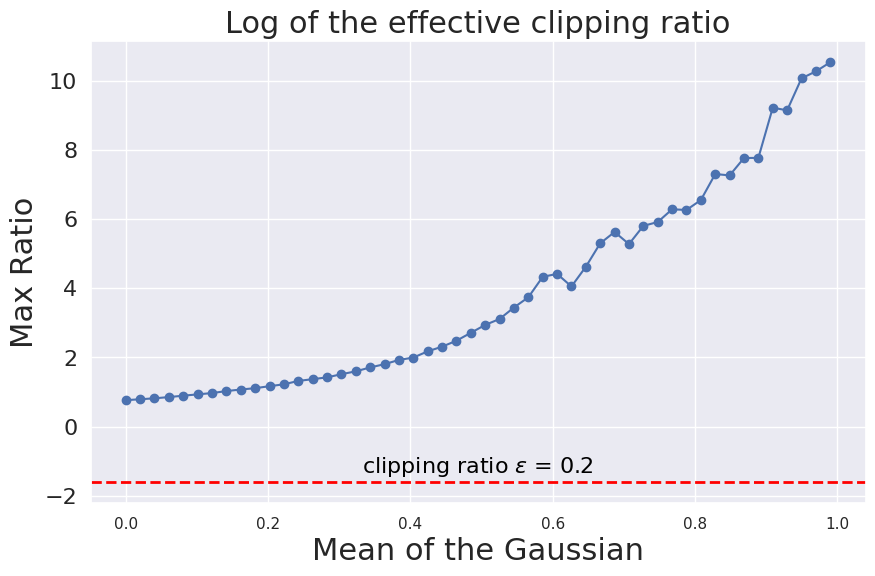

In [15]:
import seaborn as sns
import itertools

sns.set(font_scale=10)
sns.set_theme()


ratios = []
means = np.linspace(0, 0.99, 50)
stds = np.linspace(0.1,0.99, 50)[::-1]

for mean,std in zip(means,stds):    
    
    data = np.random.normal(loc=mean, scale=std, size=n)
    data2 = np.random.normal(loc=mean+np.sqrt(0.2), scale=std, size=n)
    data_bounded = np.clip(data, -1, 1)
    data_bounded2 = np.clip(data2, -1, 1)
    
    max_ratio, median_ratio = compute_clipping_ratios(data_bounded,data_bounded2)
    #print(f"Mean = {mean:.2f}, max_ratio = {max_ratio:.2f}, median_ratio = {median_ratio:.2f}")
    ratios.append(max_ratio)


plt.figure(figsize=(10,6))
plt.plot(means, np.log(ratios), marker='o')
plt.axhline(np.log(0.2), color='red', linestyle='--', linewidth=2)
plt.text(np.mean(plt.gca().get_xlim()), np.log(0.2) + 0.1, r'clipping ratio $\epsilon$ = 0.2', 
         color='black', fontsize=16, ha='center', va='bottom')

plt.yticks(fontsize=16)

plt.xlabel('Mean of the Gaussian',fontsize=22)
plt.ylabel('Max Ratio',fontsize=22)
plt.title('Log of the effective clipping ratio',fontsize=22)
plt.savefig("./plots/bound/ratio.pdf", format="pdf", bbox_inches="tight")  

plt.show()


Index(['_step', '_runtime', 'training/episodic_return', '_timestamp',
       'training/out_of_bound_percentage', 'OOB_error',
       'evaluation/undisc_policy_return'],
      dtype='object')


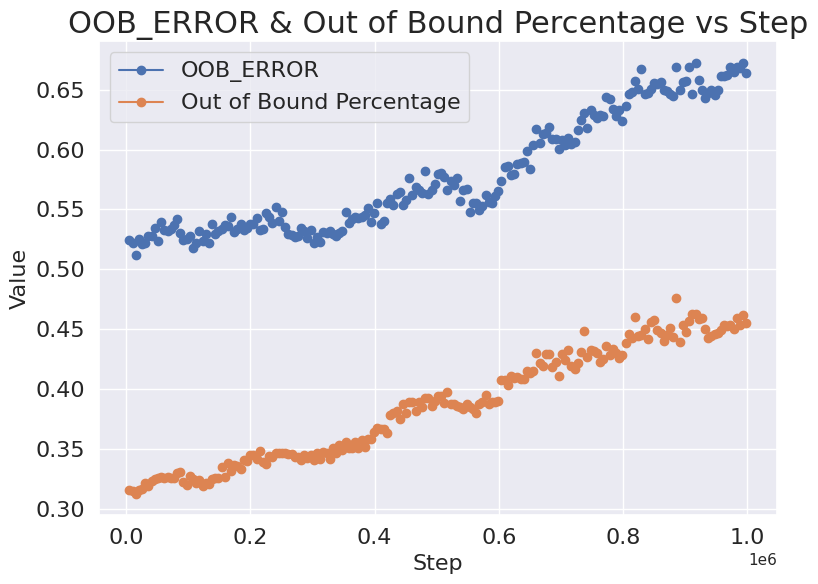

In [40]:
import pandas as pd
import wandb
import os
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import itertools

sns.set(font_scale=1.3)
sns.set_theme()


os.environ["WANDB_API_KEY"]="28996bd59f1ba2c5a8c3f2cc23d8673c327ae230"
api = wandb.Api()
entity = "mahdikallel"
project_name = "PPO_OUTBOUND"
runs = api.runs(entity + "/" + project_name)

# Select one run from the list
run = runs[0]

# Retrieve the run's history containing the necessary metrics
history = run.history(samples=10000)
print(history.columns)


# Create a figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
# Plot both on the same axis using axes[0]
axes[0].plot(history["_step"], history["OOB_error"], marker='o', label="OOB_ERROR")
axes[0].plot(history["_step"], history["training/out_of_bound_percentage"]/100, marker='o', label="Out of Bound Percentage")
axes[0].set_title("OOB_ERROR & Out of Bound Percentage vs Step", fontsize=22)
axes[0].set_xlabel("Step", fontsize=16)
axes[0].set_ylabel("Value", fontsize=16)
axes[0].tick_params(labelsize=16)
axes[0].legend(fontsize=16)

# Remove the unused second subplot
fig.delaxes(axes[1])

plt.tight_layout()
plt.savefig("./plots/bound/error.pdf", format="pdf", bbox_inches="tight")  
plt.show()

